# Reconstruction de l'environnement à l'aide d'un CNN à partir des signaux reçus

## Données

C'est un fichier .mat avec un champ "data" qui contient une matrice de 41 * 2001 signaux et un champ "map" qui contient l'état réel de la carte

Le code fait un apprentissage basique à développer plus


# 1) Imports

In [1]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import random
import copy
import os

# 2) Charger les données

In [2]:
if not os.path.exists('data'):
    print("⚠️ Erreur : Le dossier 'data' est manquant. Consultez le README pour le télécharger.")
else:
    data = loadmat('./data/moving_ball_IA_simulations_augmented.mat')["results"]
    data = data.squeeze()

# Liste python pour faciliter l'itération
list_experiments=[]

for exp in data:
    list_experiments.append(exp)

In [3]:
data = loadmat('/home/matdia/NET4256/Cassiopee_Sonar_Biomimetique_Detection/data/moving_ball_IA_simulations_augmented.mat')["results"]
data = data.squeeze()
# Liste python pour faciliter l'itération
list_experiments=[]

for exp in data:
    list_experiments.append(exp)

In [4]:
class SonarDataset(Dataset):
    def __init__(self, data_array):
        # On initialise des listes vides pour stocker nos tenseurs
        self.inputs = []
        self.targets = []

        # On boucle sur les 131 échantillons
        for i in range(data_array.shape[0]):
            echantillon = data_array[i]

            # Scipy rajoute souvent des dimensions inutiles lors de l'import MATLAB
            # Le [0,0] ou [0] permet d'accéder à la vraie matrice
            signal = echantillon['data'][0,0] # Matrice 41 x 2001
            carte = echantillon['map'][0,0]   # Matrice de la carte 2D

            # PyTorch pour les CNN attend des données sous la forme (Canal, Hauteur, Largeur)
            # On utilise unsqueeze(0) pour ajouter la dimension du "Canal" (comme une image en noir et blanc)
            signal_tensor = torch.tensor(signal, dtype=torch.float32).unsqueeze(0)
            carte_tensor = torch.tensor(carte, dtype=torch.float32).unsqueeze(0)

            self.inputs.append(signal_tensor)
            self.targets.append(carte_tensor)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

# --- Reste de ton code (identique à ta capture) ---

# 4. Instanciation du dataset
# Attention : dataset_mat doit être le tableau de shape (131,)
# ex: dataset_mat = loadmat('fichier.mat')['nom_de_la_variable'][0]
dataset = SonarDataset(data)

# 5. Séparation Train/Test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# 6. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 3) Séparer les inputs et les outputs

On garde seulement à partir de la 1200 ème colonne les signaux pour limiter la taille et ne pas compter le trajet aller.

Pour la matrice de sortie comme c'est majoritairement des 0 on ne garde que l'espace où se trouve la demi sphère.

In [5]:
list_signals=[]
list_outputs=[]

for i in range(len(list_experiments)):
    signals, caca, output=list_experiments[i]
    list_signals.append(signals[:,1200:])
    list_outputs.append(output[15:30,:])
    
X=np.array(list_signals)

# 4) Normalisation

Il est necessaire de normaliser les données pour l'apprentissage

In [6]:
mean_val = X.mean(axis=0)
std_val = X.std(axis=0)
    
# Éviter division par zéro si std_val est très petit
std_val[std_val == 0] = 1.0

X_normalized = (X - mean_val) / std_val

# 5) Visualisation des données

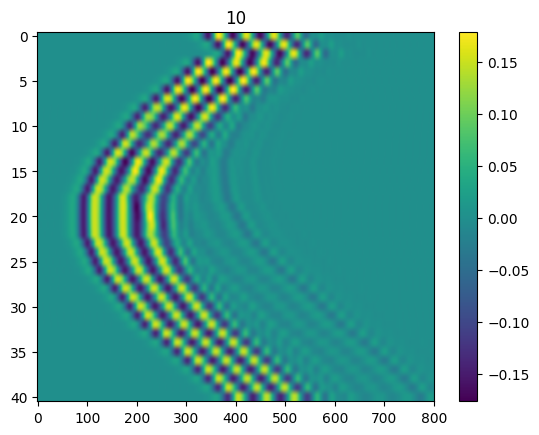

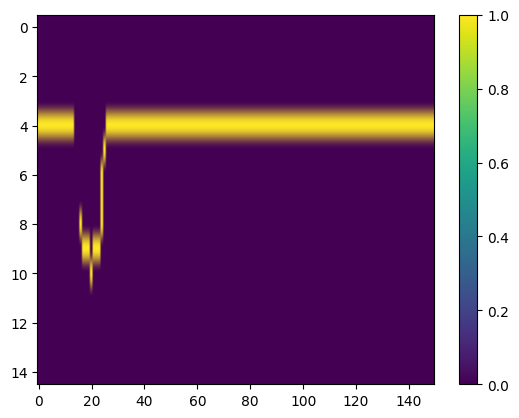

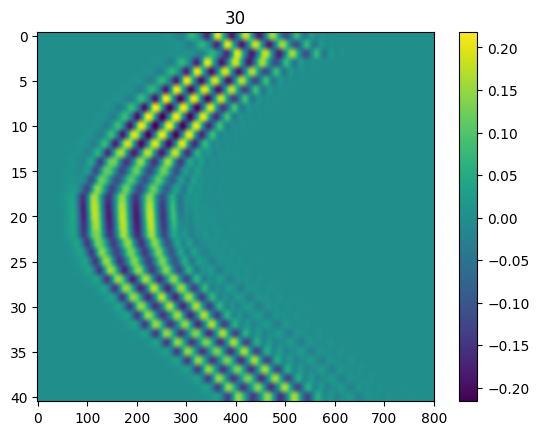

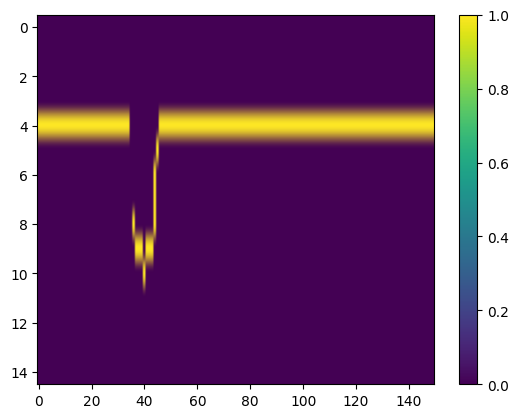

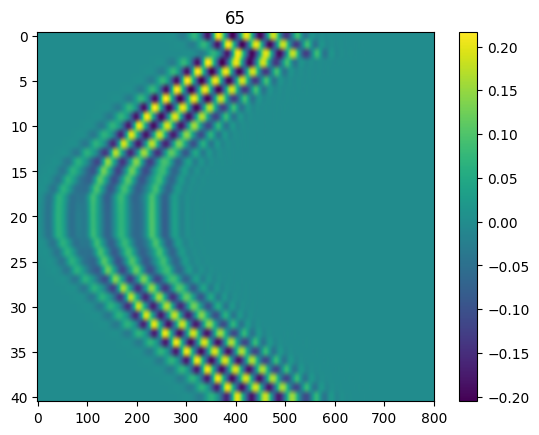

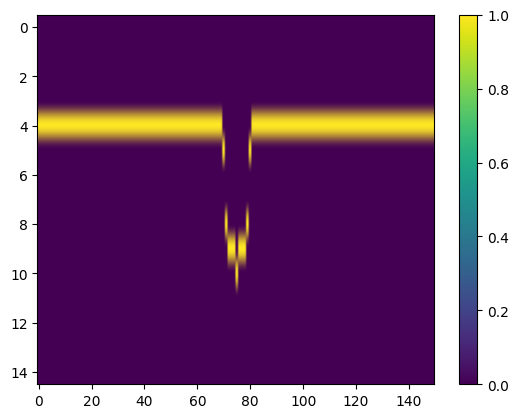

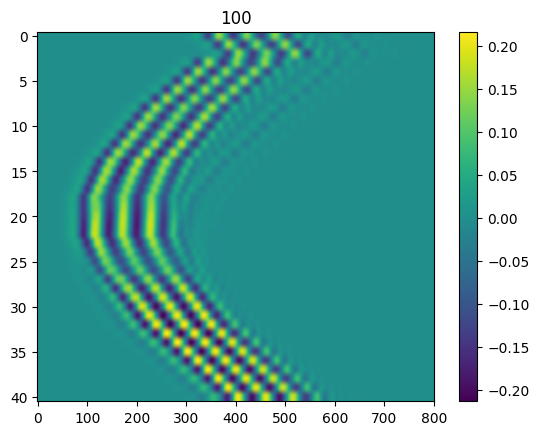

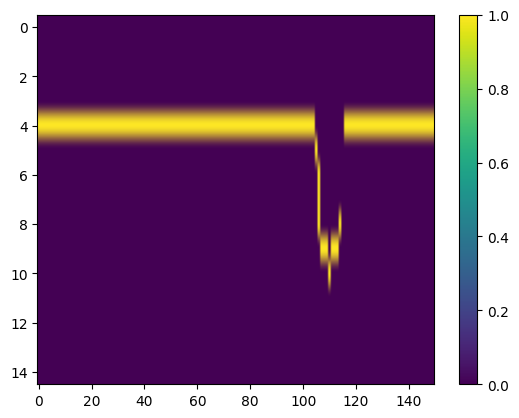

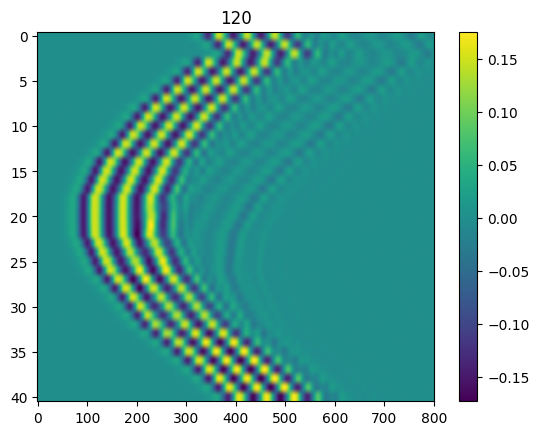

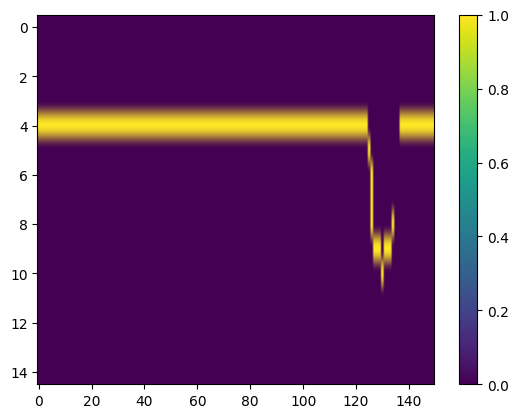

In [7]:
for example in [10,30,65,100,120]:
    plt.imshow(list_signals[example], aspect='auto')
    plt.colorbar()
    plt.title(str(example))
    plt.show()
    
    plt.imshow(list_outputs[example], aspect='auto')
    plt.colorbar()
    plt.show()

## (Optionnel) Associer les signaux pour pas qu'il y ai t de conflit avec le code de Maxime

In [8]:
X = X_normalized
y = list_outputs

# 6) Dataset personalisé

In [9]:
class SignalToImageDataset(Dataset):
    def __init__(self, X, y):
        # Conversion en tenseurs
        X = np.array(X, dtype=np.float32)  # (N, 41, 2001)
        y = np.array(y, dtype=np.float32)  # (N, 15, 150)
        
        self.X = torch.tensor(X).unsqueeze(1)  # (N, 1, 41, 2001)
        self.y = torch.tensor(y).unsqueeze(1) 
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 7) Modèle CNN

In [10]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)   # ↓
        )
        
        # Taille après encodeur (calcul dynamique)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 41, 2001)
            out = self.encoder(dummy)
            enc_h, enc_w = out.shape[2], out.shape[3]

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 8, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

        # On ajuste la dernière couche pour donner exactement (15,150)
        self.output_crop = (15, 150)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # Recadrer au cas où la taille n'est pas exacte
        h, w = self.output_crop
        x = x[:, :, :h, :w]
        return x
    
def pixel_accuracy(outputs, targets, threshold=0.5):
    """
    Calcule l'accuracy pixel par pixel.
    outputs : (N, 2250) -> probabilités
    targets : (N, 2250) -> 0 ou 1
    """
    preds = (outputs >= threshold).float()
    correct = (preds == targets).float().sum()
    total = targets.numel()
    return (correct / total).item()

def show_test_predictions(model, test_loader, device, num_samples=3, threshold=0.5):
    """
    Affiche num_samples prédictions du test set, reshaped en (15,150).
    """
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # Binarisation selon le seuil
            preds = (outputs >= threshold).float()
            preds=outputs

            for i in range(inputs.size(0)):
                pred_img = preds[i].view(15, 150).cpu().numpy()
                target_img = targets[i].view(15, 150).cpu().numpy()

                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(target_img, cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(pred_img, cmap="gray")
                axes[1].set_title("Prédiction")
                axes[1].axis("off")

                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

# 7b) Fonction de perte : BCE + Dice Loss

La **Dice Loss** mesure le chevauchement entre la prédiction et la vérité terrain.
Elle est particulièrement adaptée aux données déséquilibrées et force le modèle à bien reconstruire la **forme** complète de l'objet, pas seulement sa position.

`Loss = BCE + Dice`

# 7c) Architecture U-Net avec skip connections

Le U-Net relie chaque niveau de l'encodeur directement au décodeur correspondant via des **skip connections**.
Cela permet de préserver les détails spatiaux fins (forme, contours) qui sont perdus dans le goulot d'étranglement du CNN simple.

Chaque bloc inclut aussi une **BatchNorm** pour stabiliser l'entraînement.

In [11]:
class DoubleConv(nn.Module):
    """Deux convolutions consécutives avec BatchNorm et ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encodeur
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Goulot d'étranglement
        self.bottleneck = DoubleConv(128, 256)

        # Décodeur
        self.up3  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)   # 128 (up) + 128 (skip)

        self.up2  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)    # 64  (up) + 64  (skip)

        self.up1  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)     # 32  (up) + 32  (skip)

        self.final   = nn.Conv2d(32, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

        self.output_size = (15, 150)

    def _crop(self, skip, target):
        """Recadre le skip pour correspondre à la taille de target."""
        _, _, h, w = target.shape
        return skip[:, :, :h, :w]

    def forward(self, x):
        # Encodeur + skip connections
        s1 = self.enc1(x)                    # (32, 41, 801)
        s2 = self.enc2(self.pool(s1))        # (64, 20, 400)
        s3 = self.enc3(self.pool(s2))        # (128, 10, 200)

        # Goulot
        b = self.bottleneck(self.pool(s3))   # (256, 5, 100)

        # Décodeur avec skip connections
        d3 = self.up3(b)                                      # (128, 10, 200)
        d3 = self.dec3(torch.cat([d3, self._crop(s3, d3)], dim=1))

        d2 = self.up2(d3)                                     # (64, 20, 400)
        d2 = self.dec2(torch.cat([d2, self._crop(s2, d2)], dim=1))

        d1 = self.up1(d2)                                     # (32, ~40, ~800)
        d1 = self.dec1(torch.cat([d1, self._crop(s1, d1)], dim=1))

        out = self.sigmoid(self.final(d1))

        # Recadrer à la taille de sortie cible
        h, w = self.output_size
        return out[:, :, :h, :w]

In [12]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCELoss()

    def forward(self, outputs, targets):
        bce_loss = self.bce(outputs, targets)

        # Dice Loss
        smooth = 1e-6
        outputs_flat = outputs.reshape(outputs.size(0), -1)
        targets_flat = targets.reshape(targets.size(0), -1)
        intersection = (outputs_flat * targets_flat).sum(dim=1)
        dice = 1 - (2 * intersection + smooth) / (outputs_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)
        dice_loss = dice.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

# 8) Fonction d'entrainement avec découpage

In [13]:
def train_and_validate(X, y, model_class, epochs=200, batch_size=8, lr=1e-3, patience=20):
    dataset = SignalToImageDataset(X, y)

    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)

    lengths = [80, 25, 26]
    train_set, val_set, test_set = random_split(dataset, lengths)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    
    model = model_class()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = BCEDiceLoss(bce_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Early stopping vars
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    # Pour suivi des métriques
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0
        train_acc_sum = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
            train_acc_sum += pixel_accuracy(outputs, targets)

        # ---- Validation ----
        model.eval()
        val_loss_sum = 0.0
        val_acc_sum = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss_sum += loss.item()
                val_acc_sum += pixel_accuracy(outputs, targets)

        train_loss = train_loss_sum / len(train_loader)
        train_acc = train_acc_sum / len(train_loader)
        val_loss = val_loss_sum / len(val_loader)
        val_acc = val_acc_sum / len(val_loader)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} "
              f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # ---- Early stopping check ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # ---- Restore best model ----
    model.load_state_dict(best_model_wts)

    # ---- Test set evaluation ----
    model.eval()
    test_loss_sum = 0.0
    test_acc_sum = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss_sum += loss.item()
            test_acc_sum += pixel_accuracy(outputs, targets)

    test_loss = test_loss_sum / len(test_loader)
    test_acc = test_acc_sum / len(test_loader)

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    
    # ---- Courbes ----
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.axhline(y=test_loss, color='r', linestyle='--', label=f"Test Loss ({test_loss:.4f})")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss vs Epochs")

    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.axhline(y=test_acc, color='r', linestyle='--', label=f"Test Acc ({test_acc:.4f})")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy vs Epochs")

    plt.show()

    # ---- Sauvegarde du modèle ----
    torch.save(model.state_dict(), "model_unet.pth")
    print("Modèle sauvegardé dans model_unet.pth")

    return model, train_loader, val_loader, test_loader

# 9) Lancement de l'entrainement

In [ ]:
model, train_loader, val_loader, test_loader = train_and_validate(X, y, UNet)

# 9b) Recharger le modèle sans réentraîner

Exécuter cette cellule si le modèle a déjà été entraîné et sauvegardé (`model_cnn.pth` existe).

In [ ]:
if os.path.exists("model_unet.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UNet().to(device)
    model.load_state_dict(torch.load("model_unet.pth", map_location=device))
    model.eval()

    # Recréer les dataloaders pour la visualisation
    dataset = SignalToImageDataset(X, y)
    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)
    train_set, val_set, test_set = random_split(dataset, [80, 25, 26])
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False)

    print("Modèle chargé depuis model_cnn.pth")
else:
    print("⚠️ Aucun fichier model_cnn.pth trouvé. Lance d'abord la cellule d'entraînement (section 9).")

# 10) Présentation des résultats

In [ ]:
def show_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = outputs.cpu().numpy()

            for i in range(inputs.size(0)):
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(targets[i].cpu().squeeze(), cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(preds[i].squeeze(), cmap="gray")
                axes[1].set_title("Prédiction CNN")
                axes[1].axis("off")
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return
                
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
show_predictions(model, test_loader, device, num_samples=20)

# 11) Diagnostic des prédictions

## 11a) Distribution des valeurs prédites

Vérifie si le modèle prédit des valeurs variées ou s'effondre vers 0 ou 1.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu().numpy().flatten())
        all_targets.append(targets.cpu().numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Histogramme des valeurs prédites
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(all_preds, bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Valeur prédite (sigmoid)")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des prédictions")
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil 0.5")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_targets, bins=10, color='darkorange', edgecolor='black')
plt.xlabel("Valeur réelle")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des vérités terrain")

plt.tight_layout()
plt.show()

# Ratio de pixels positifs dans la vérité terrain
ratio_positifs = all_targets.mean()
print(f"Ratio de pixels positifs (=1) dans la vérité terrain : {ratio_positifs:.4f} ({ratio_positifs*100:.2f}%)")
print(f"Moyenne des prédictions : {all_preds.mean():.4f}")
print(f"Std des prédictions     : {all_preds.std():.4f}")

## 11b) Métriques de segmentation : Précision, Rappel, F1, IoU

La **pixel accuracy** seule est trompeuse quand les classes sont déséquilibrées.
- **Précision** : parmi les pixels prédits à 1, combien sont vrais ?
- **Rappel** : parmi les pixels réels à 1, combien sont détectés ?
- **F1** : moyenne harmonique précision/rappel
- **IoU** (Intersection over Union) : métrique standard en segmentation

In [ ]:
def compute_metrics(preds_prob, targets, threshold=0.5):
    preds = (preds_prob >= threshold).astype(float)
    
    TP = ((preds == 1) & (targets == 1)).sum()
    FP = ((preds == 1) & (targets == 0)).sum()
    FN = ((preds == 0) & (targets == 1)).sum()
    TN = ((preds == 0) & (targets == 0)).sum()
    
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    iou       = TP / (TP + FP + FN + 1e-8)
    accuracy  = (TP + TN) / (TP + FP + FN + TN + 1e-8)
    
    return {"Accuracy": accuracy, "Précision": precision, "Rappel": recall, "F1": f1, "IoU": iou}

metrics = compute_metrics(all_preds, all_targets)
print("=== Métriques sur le test set ===")
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")

# Courbe F1 selon le seuil
thresholds = np.linspace(0, 1, 50)
f1_scores  = [compute_metrics(all_preds, all_targets, t)["F1"] for t in thresholds]
iou_scores = [compute_metrics(all_preds, all_targets, t)["IoU"] for t in thresholds]

best_t = thresholds[np.argmax(f1_scores)]
print(f"\nMeilleur seuil (F1 max) : {best_t:.2f}  →  F1 = {max(f1_scores):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores,  label="F1")
plt.plot(thresholds, iou_scores, label="IoU")
plt.axvline(x=best_t, color='red', linestyle='--', label=f"Seuil optimal ({best_t:.2f})")
plt.xlabel("Seuil de binarisation")
plt.ylabel("Score")
plt.title("F1 et IoU selon le seuil")
plt.legend()
plt.show()

## 11c) Visualisation côte à côte avec superposition des erreurs

Rouge = faux positifs (prédit 1, réel 0) | Bleu = faux négatifs (prédit 0, réel 1)

In [ ]:
def show_diagnostic(model, loader, device, num_samples=5, threshold=0.5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            for i in range(inputs.size(0)):
                pred_prob = outputs[i].squeeze().cpu().numpy()
                pred_bin  = (pred_prob >= threshold).astype(float)
                target    = targets[i].squeeze().cpu().numpy()

                # Carte d'erreurs RGB
                error_map = np.zeros((*target.shape, 3))
                error_map[(pred_bin == 1) & (target == 1)] = [0, 1, 0]   # Vert  : vrai positif
                error_map[(pred_bin == 1) & (target == 0)] = [1, 0, 0]   # Rouge : faux positif
                error_map[(pred_bin == 0) & (target == 1)] = [0, 0, 1]   # Bleu  : faux négatif

                fig, axes = plt.subplots(1, 4, figsize=(16, 3))

                axes[0].imshow(target, cmap="gray", vmin=0, vmax=1)
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(pred_prob, cmap="hot", vmin=0, vmax=1)
                axes[1].set_title("Prédiction (probabilité)")
                axes[1].axis("off")

                axes[2].imshow(pred_bin, cmap="gray", vmin=0, vmax=1)
                axes[2].set_title(f"Prédiction (seuil={threshold})")
                axes[2].axis("off")

                axes[3].imshow(error_map)
                axes[3].set_title("Erreurs (rouge=FP, bleu=FN, vert=TP)")
                axes[3].axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

show_diagnostic(model, test_loader, device, num_samples=5, threshold=best_t)